# Scenario Comparison Analysis

In [74]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [75]:
base_config_name = "germany_base"
cluster = "450"
home = "/home/lucakristin/Desktop/my_pypsa"

In [76]:
scenario_config_name ="germany_scenario"
scenario_config_dir = f"{home}/pypsa-eur/config/scenario_configs"
scenario_config_path = f"{scenario_config_dir}/{scenario_config_name}.json"

---
# Building networks

Build the base network without transmission projects (with 450 clusters and from the `germany_base.yaml` file)

```bash
# Build the network (dry run)
snakemake -n --cores 6 "resources/germany_base/networks/base_s_450_elec_.nc" --configfile config/config.germany_base.yaml

# Solve the base network -> for line loads
snakemake -n -call solve_elec_networks --configfile config/config.germany_base.yaml
```

## 2. Create scenario network 

In [117]:
# First, ensure the scenario is created by running the script.
# This modifies the base network and saves it as the scenario network.
!python ../create_germany_scenario.py --scenario-config-file {scenario_config_path} --home {home}

Loading scenario config from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/scenario_configs/germany_scenario.json
Loading base network from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/resources/germany_base/networks/base_s_450_elec_.nc
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
--- Applying modifications ---
Modifying generator capacity mix while keeping the total capacity constant.
Current total capacity of selected carriers: 226803.92 MW
Carrier 'solar': current 48771.25 MW -> target 22680.39 MW (10.0% share); selected band 48771.25 MW -> 22680.39 MW (factor 0.4650)
Carrier 'onwind': current 73332.07 MW -> target 68041.18 MW (30.0% share); selected band 39140.61 MW -> 33849.72 MW (factor 0.8648)
Carrier 'offwind-ac': current 11163.74 MW -> target 113401.96 MW (50.0% share); selected band 11163.74 MW -> 113401.96 MW (fact

## 3. Load unsolved networks to see modifications

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


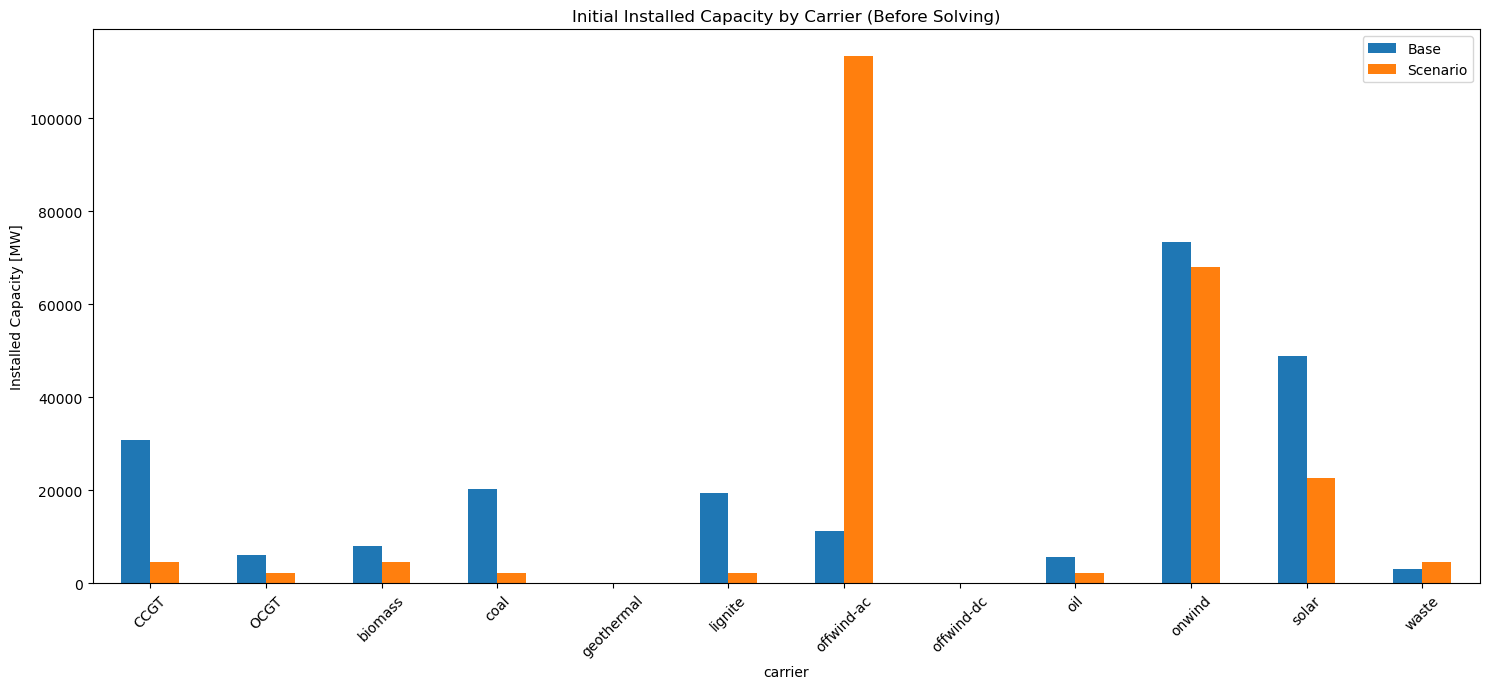

In [118]:
# --- Load Scenario Network ---
scenario_network_path_unsolved = f"{home}/pypsa-eur/resources/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario_unsolved = pypsa.Network(scenario_network_path_unsolved, name="Scenario Network")

# Load the unsolved base network to compare initial capacities
base_network_path_unsolved = f"{home}/pypsa-eur/resources/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base_unsolved = pypsa.Network(base_network_path_unsolved)

p_nom_base = n_base_unsolved.generators.groupby("carrier").p_nom.sum()
p_nom_scenario = n_scenario_unsolved.generators.groupby("carrier").p_nom.sum()

df = pd.DataFrame({
    "Base": p_nom_base,
    "Scenario": p_nom_scenario
}).dropna()

df.plot(kind="bar", figsize=(15, 7), rot=45)
plt.ylabel("Installed Capacity [MW]")
plt.title("Initial Installed Capacity by Carrier (Before Solving)")
plt.tight_layout()
plt.show()

In [119]:
# Capacity share by generator carrier for the scenario network
carrier_capacity = n_base_unsolved.generators.groupby("carrier").p_nom.sum()
carrier_capacity_pct = 100 * carrier_capacity / carrier_capacity.sum()
print(base_config_name)
print("Capacity share by carrier (% of total installed generator capacity):")
print(carrier_capacity_pct.sort_values(ascending=False).round(2).astype(str) + "%")

germany_base
Capacity share by carrier (% of total installed generator capacity):
carrier
onwind        32.33%
solar          21.5%
CCGT          13.57%
coal           8.97%
lignite        8.58%
offwind-ac     4.92%
biomass        3.54%
OCGT           2.69%
oil            2.51%
waste          1.38%
geothermal     0.01%
offwind-dc      0.0%
Name: p_nom, dtype: object


In [120]:
# Capacity share by generator carrier for the scenario network
carrier_capacity = n_scenario_unsolved.generators.groupby("carrier").p_nom.sum()
carrier_capacity_pct = 100 * carrier_capacity / carrier_capacity.sum()
print(scenario_config_name)
print("Capacity share by carrier (% of total installed generator capacity):")
print(carrier_capacity_pct.sort_values(ascending=False).round(2).astype(str) + "%")

germany_scenario
Capacity share by carrier (% of total installed generator capacity):
carrier
offwind-ac    49.99%
onwind         30.0%
solar          10.0%
CCGT            2.0%
biomass         2.0%
waste           2.0%
coal            1.0%
OCGT            1.0%
oil             1.0%
lignite         1.0%
geothermal     0.01%
offwind-dc      0.0%
Name: p_nom, dtype: object


---
# Solving networks

## 1. Check if config.yaml exists before solving 

In [121]:
# Check that a matching scenario config file exists before creating the network.
scenario_yaml_path = f"{home}/pypsa-eur/config/config.{scenario_config_name}.yaml"
if not os.path.isfile(scenario_yaml_path):
    raise FileNotFoundError(
        f"Missing scenario config file: {scenario_yaml_path}\n"
        f"Expected a file named config.{scenario_config_name}.yaml in pypsa-eur/config/."
    )
print(f"Found scenario config: {scenario_yaml_path}")

Found scenario config: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/config.germany_scenario.yaml


## 2. Solve the network -> for line loads
```bash
snakemake -n -call solve_elec_networks --configfile config/config.germany_scenario.yaml
```

#### Unlock command

```bash
cd pypsa-eur && conda activate pypsa-eur && snakemake -call solve_elec_networks --configfile config/config.germany_scenario_1.yaml --unlock
```

```
Using workflow specific profile profiles/default for setting default command line arguments.
Config file config/config.default.yaml is extended by additional config specified via the command line.
Config file config/plotting.default.yaml is extended by additional config specified via the command line.
Unlocked working directory.
```

## 3. Load solved networks

In [122]:
# --- Load Base Network ---
base_network_path = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base = pypsa.Network(base_network_path, name="Base Network")
n_base.name = "Base Network"

# --- Load Scenario Network ---
scenario_network_path = f"{home}/pypsa-eur/results/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario = pypsa.Network(scenario_network_path, name="Scenario Network")
n_scenario.name = "Scenario Network"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


## 4. Comparison Plots

### 4.1 Grid Congestion and Curtailment

##### Line Loading Comparison

BASE NETWORK - Lines with >80% Average Loading:
167: 200.2%
240: 148.5%
520: 111.8%
569: 106.0%
99: 102.7%
84: 101.1%
66: 93.1%
235: 89.6%
315: 87.9%
488: 87.2%

SCENARIO NETWORK - Lines with >80% Average Loading:
240: 818.8%
90: 488.6%
569: 449.7%
392: 390.3%
57: 361.8%
598: 359.1%
310: 357.6%
311: 357.5%
493: 352.7%
84: 348.7%


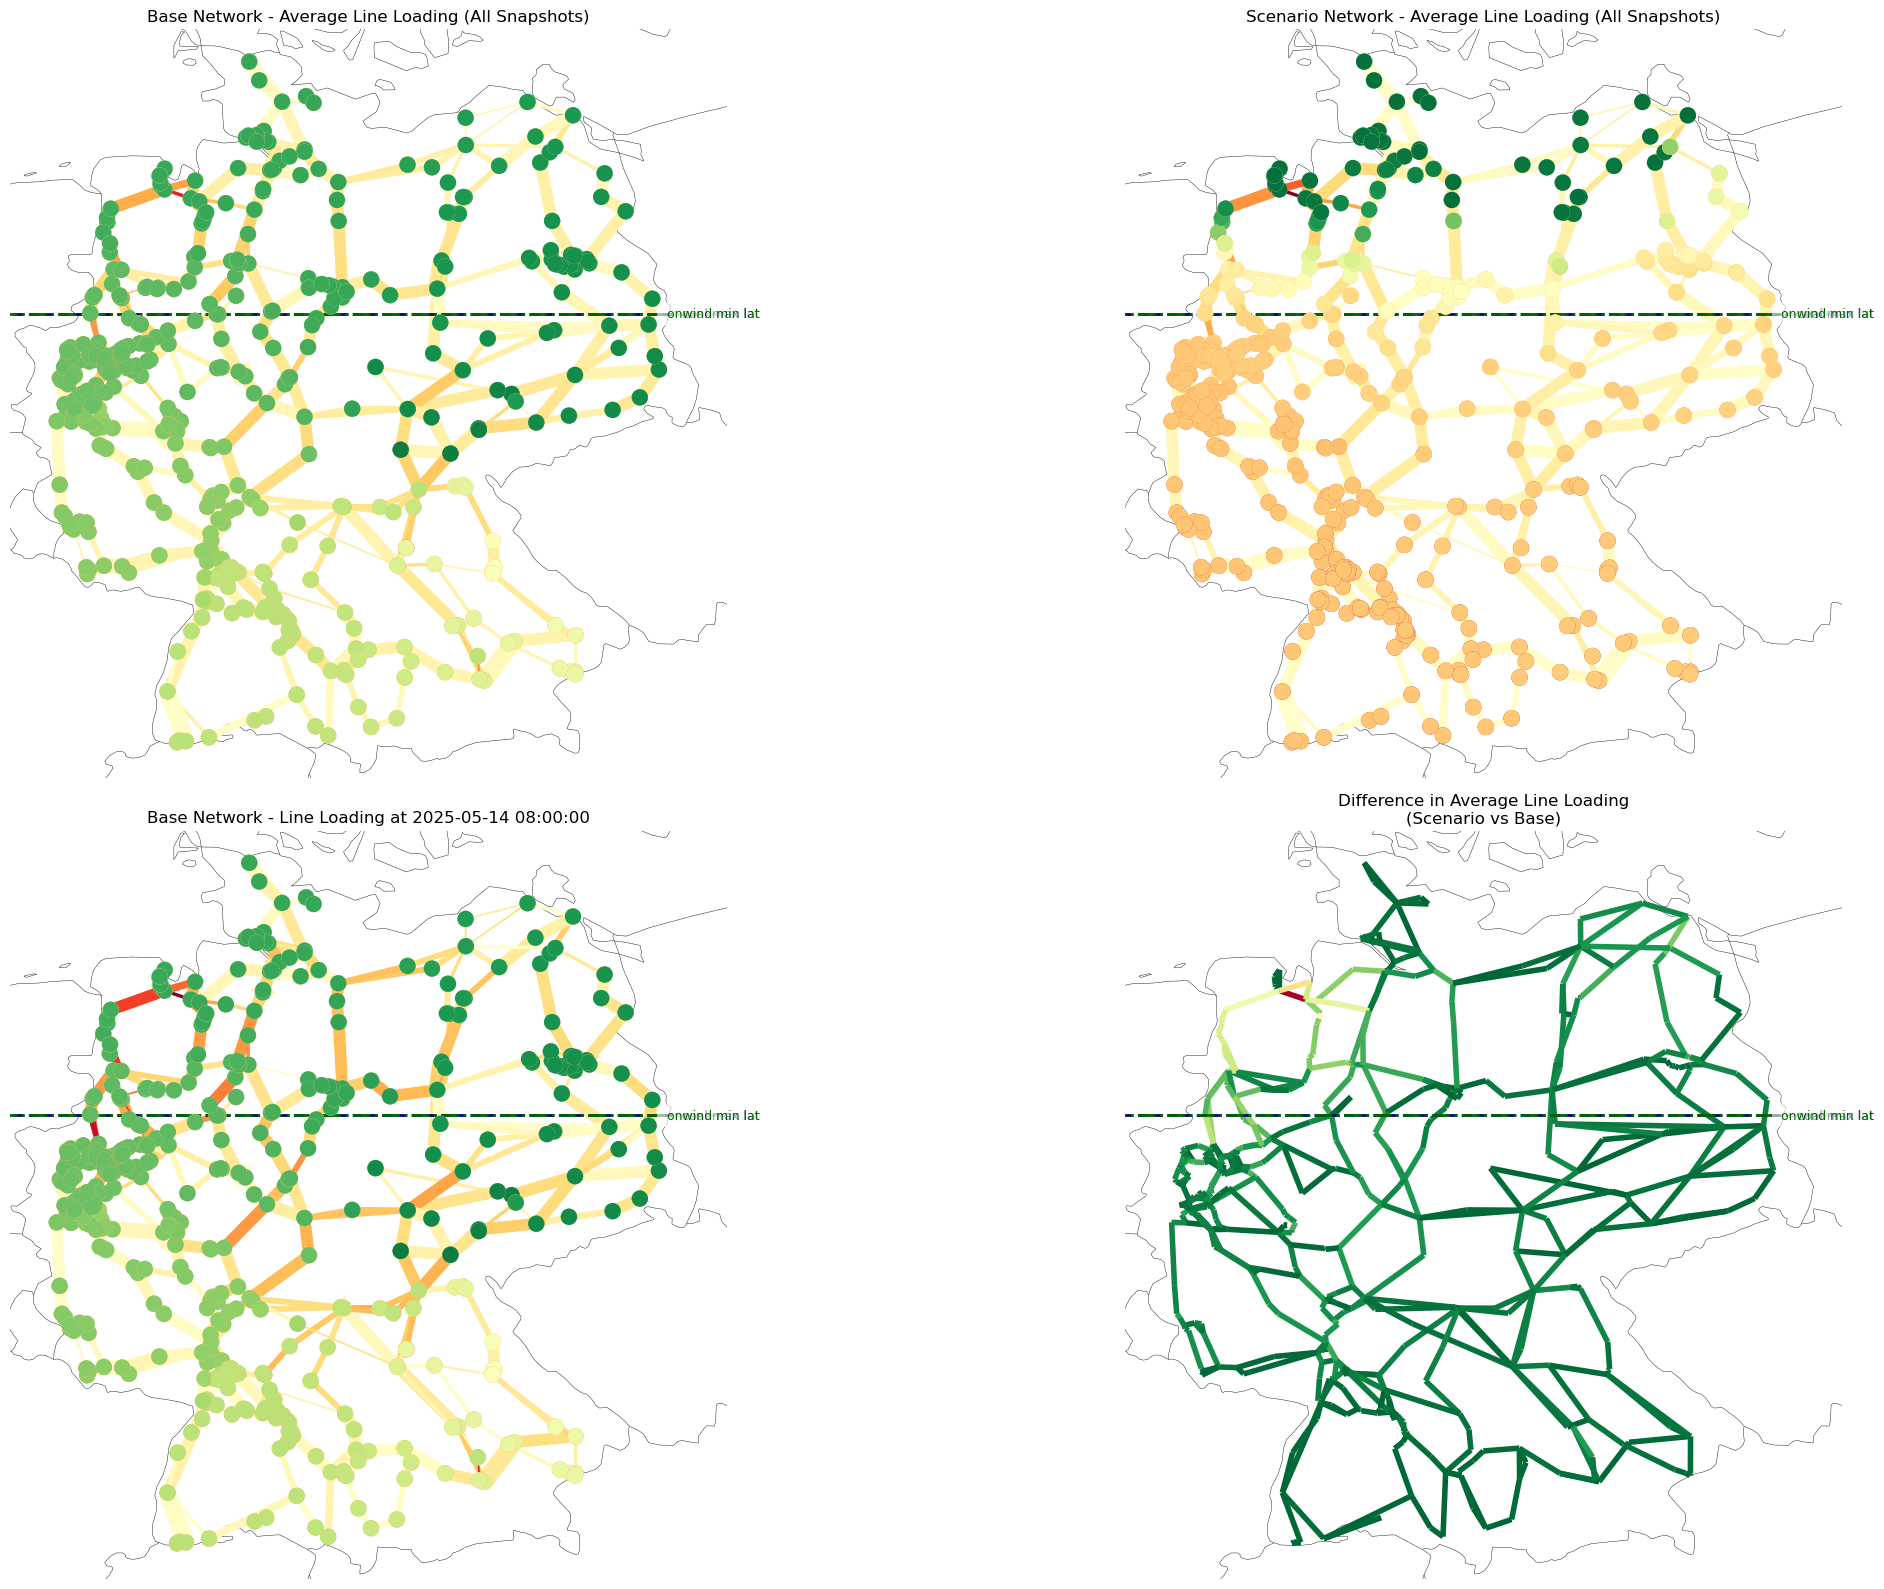


CONGESTION STATISTICS

Base Network:
  Average loading across all lines: 25.44%
  Max average loading: 200.20%
  Lines with >80% avg loading: 19
  Lines with >90% avg loading: 7

Scenario Network:
  Average loading across all lines: 66.53%
  Max average loading: 818.81%
  Lines with >80% avg loading: 155
  Lines with >90% avg loading: 131

Difference (Scenario - Base):
  Max increase in loading: 670.28%
  Max decrease in loading: -94.74%


In [135]:
snapshot = n_base.snapshots[8]

bus_size_factor = 1e9
branch_width_factor = 400

# --- Calculate maximum loading across all snapshots ---
#max_loading_base = (n_base.lines_t.p0.abs() / n_base.lines.s_nom).max()
#max_loading_scenario = (n_scenario.lines_t.p0.abs() / n_scenario.lines.s_nom).max()

# --- Identify congested lines (>80% and >90% of capacity) ---
#congested_80_base = max_loading_base[max_loading_base > 0.8].sort_values(ascending=False)
#congested_80_scenario = max_loading_scenario[max_loading_scenario > 0.8].sort_values(ascending=False)

# --- Calculate average loading across all snapshots ---
avg_loading_base = (n_base.lines_t.p0.abs() / n_base.lines.s_nom).mean()
avg_loading_scenario = (n_scenario.lines_t.p0.abs() / n_scenario.lines.s_nom).mean()

# --- Identify congested lines (>80% and >90% of capacity) ---
congested_80_base = avg_loading_base[avg_loading_base > 0.8].sort_values(ascending=False)
congested_80_scenario = avg_loading_scenario[avg_loading_scenario > 0.8].sort_values(ascending=False)


print("=" * 70)
print("BASE NETWORK - Lines with >80% Average Loading:")
print("=" * 70)
if len(congested_80_base) > 0:
    for line_idx, loading in congested_80_base.head(10).items():
        print(f"{line_idx}: {loading:.1%}")
else:
    print("No lines with >80% average loading")

print("\n" + "=" * 70)
print("SCENARIO NETWORK - Lines with >80% Average Loading:")
print("=" * 70)
if len(congested_80_scenario) > 0:
    for line_idx, loading in congested_80_scenario.head(10).items():
        print(f"{line_idx}: {loading:.1%}")
else:
    print("No lines with >80% average loading")

# --- Create enhanced visualization ---
fig, axes = plt.subplots(2, 2, figsize=(26, 16), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title, is_difference=False):
    # Calculate energy balance for bus sizes
    eb = (
        n.statistics.energy_balance(
            groupby=["bus", "carrier"],
            components=["Generator", "Load", "StorageUnit"],
        )
        .groupby(["bus", "carrier"])
        .sum()
    )

    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]

    
    if is_difference:
        # For difference plot
        n.plot(
            ax=ax,
            geomap=True,
            title=title,
            bus_sizes=0,

            line_colors=loading_avg,
            line_cmap="RdYlGn_r",  # Red for high differences, green for low
            line_width=4,
            link_width=4,
        )
    else:
        # For loading plots
        n.plot(
            ax=ax,
            geomap=True,
            title=title,
            bus_sizes=0.01, # Size buses by marginal price
            bus_colors=peak_prices,       # Color buses by marginal price
            bus_cmap='RdYlGn_r',
            line_colors=loading_avg,
            line_cmap="YlOrRd",  # Yellow to Red for increasing congestion
            line_width=n.lines.s_nom / branch_width_factor,
            link_width=n.links.p_nom / branch_width_factor,
        )

# Row 1: Average Loading Over All Snapshots
plot_network_congestion(n_base, avg_loading_base, axes[0, 0], 
                        "Base Network - Average Line Loading (All Snapshots)")
plot_network_congestion(n_scenario, avg_loading_scenario, axes[0, 1], 
                        "Scenario Network - Average Line Loading (All Snapshots)")

# Row 2, Col 1: Single snapshot for context
loading_base_snapshot = n_base.lines_t.p0.loc[snapshot].abs() / n_base.lines.s_nom
loading_scenario_snapshot = n_scenario.lines_t.p0.loc[snapshot].abs() / n_scenario.lines.s_nom

plot_network_congestion(n_base, loading_base_snapshot, axes[1, 0], 
                        f"Base Network - Line Loading at {snapshot}")

# Row 2, Col 2: Difference in average loading
loading_diff_avg = (avg_loading_scenario - avg_loading_base).abs()
plot_network_congestion(n_base, loading_diff_avg, axes[1, 1], 
                        "Difference in Average Line Loading\n(Scenario vs Base)", 
                        is_difference=True)


coal_max_lat = 52
onwind_min_lat = 52


# --- Draw latitude marker lines on all map axes if latitudes are available ---
for ax in axes.flat:
    try:
        lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
    except Exception:
        lon_min, lon_max = -11, 35
    if coal_max_lat is not None:
        ax.plot([lon_min, lon_max], [coal_max_lat, coal_max_lat], transform=ccrs.PlateCarree(),
                color='navy', linestyle='--', linewidth=2)
        ax.text(lon_max, coal_max_lat, ' coal max lat', transform=ccrs.PlateCarree(),
                va='center', ha='right', color='navy', fontsize=9, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    if onwind_min_lat is not None:
        ax.plot([lon_min, lon_max], [onwind_min_lat, onwind_min_lat], transform=ccrs.PlateCarree(),
                color='darkgreen', linestyle='-.', linewidth=2)
        ax.text(lon_max, onwind_min_lat, ' onwind min lat', transform=ccrs.PlateCarree(),
                va='center', ha='right', color='darkgreen', fontsize=9, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.show()

# --- Print congestion statistics ---
print("\n" + "=" * 70)
print("CONGESTION STATISTICS")
print("=" * 70)
print(f"\nBase Network:")
print(f"  Average loading across all lines: {avg_loading_base.mean():.2%}")
print(f"  Max average loading: {avg_loading_base.max():.2%}")
print(f"  Lines with >80% avg loading: {(avg_loading_base > 0.8).sum()}")
print(f"  Lines with >90% avg loading: {(avg_loading_base > 0.9).sum()}")

print(f"\nScenario Network:")
print(f"  Average loading across all lines: {avg_loading_scenario.mean():.2%}")
print(f"  Max average loading: {avg_loading_scenario.max():.2%}")
print(f"  Lines with >80% avg loading: {(avg_loading_scenario > 0.8).sum()}")
print(f"  Lines with >90% avg loading: {(avg_loading_scenario > 0.9).sum()}")

print(f"\nDifference (Scenario - Base):")
print(f"  Max increase in loading: {(avg_loading_scenario - avg_loading_base).max():.2%}")
print(f"  Max decrease in loading: {(avg_loading_scenario - avg_loading_base).min():.2%}")
print("=" * 70)

##### Offshore Wind Curtailment

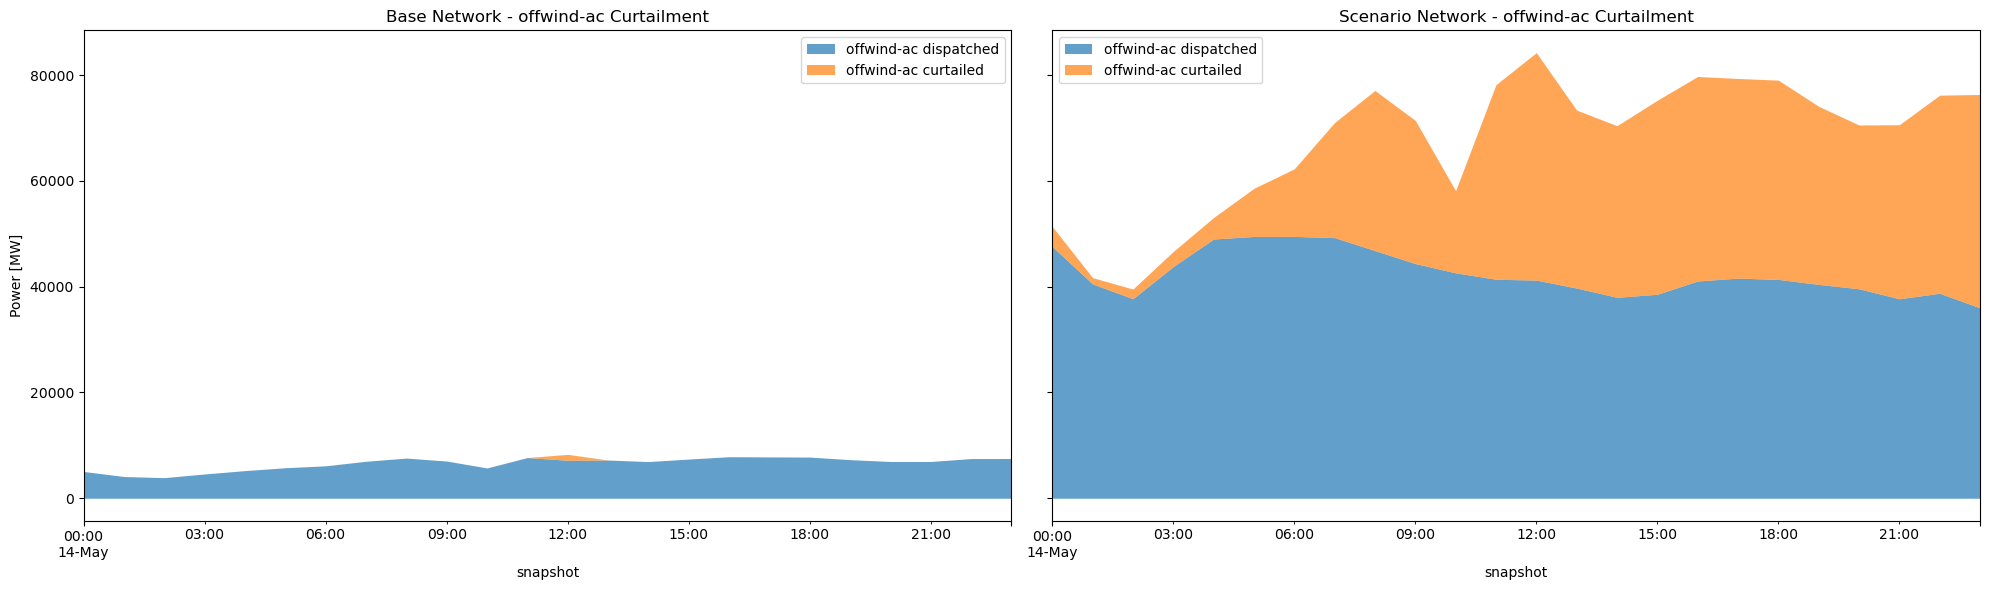

In [124]:
def plot_curtailment(n, carrier, ax):
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    p_dispatched = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed = p_available - p_dispatched
    
    # Correct for any minor negative values from floating point inaccuracies
    p_curtailed[p_curtailed < 0] = 0
    
    df = pd.DataFrame({
        f"{carrier} dispatched": p_dispatched[carrier],
        f"{carrier} curtailed": p_curtailed[carrier]
    })
    
    df.plot(kind="area", ax=ax, lw=0, alpha=0.7)
    ax.set_title(f"{n.name} - {carrier} Curtailment")
    ax.set_ylabel("Power [MW]")

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

plot_curtailment(n_base, "offwind-ac", axes[0])
plot_curtailment(n_scenario, "offwind-ac", axes[1])

plt.tight_layout()
plt.show()

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

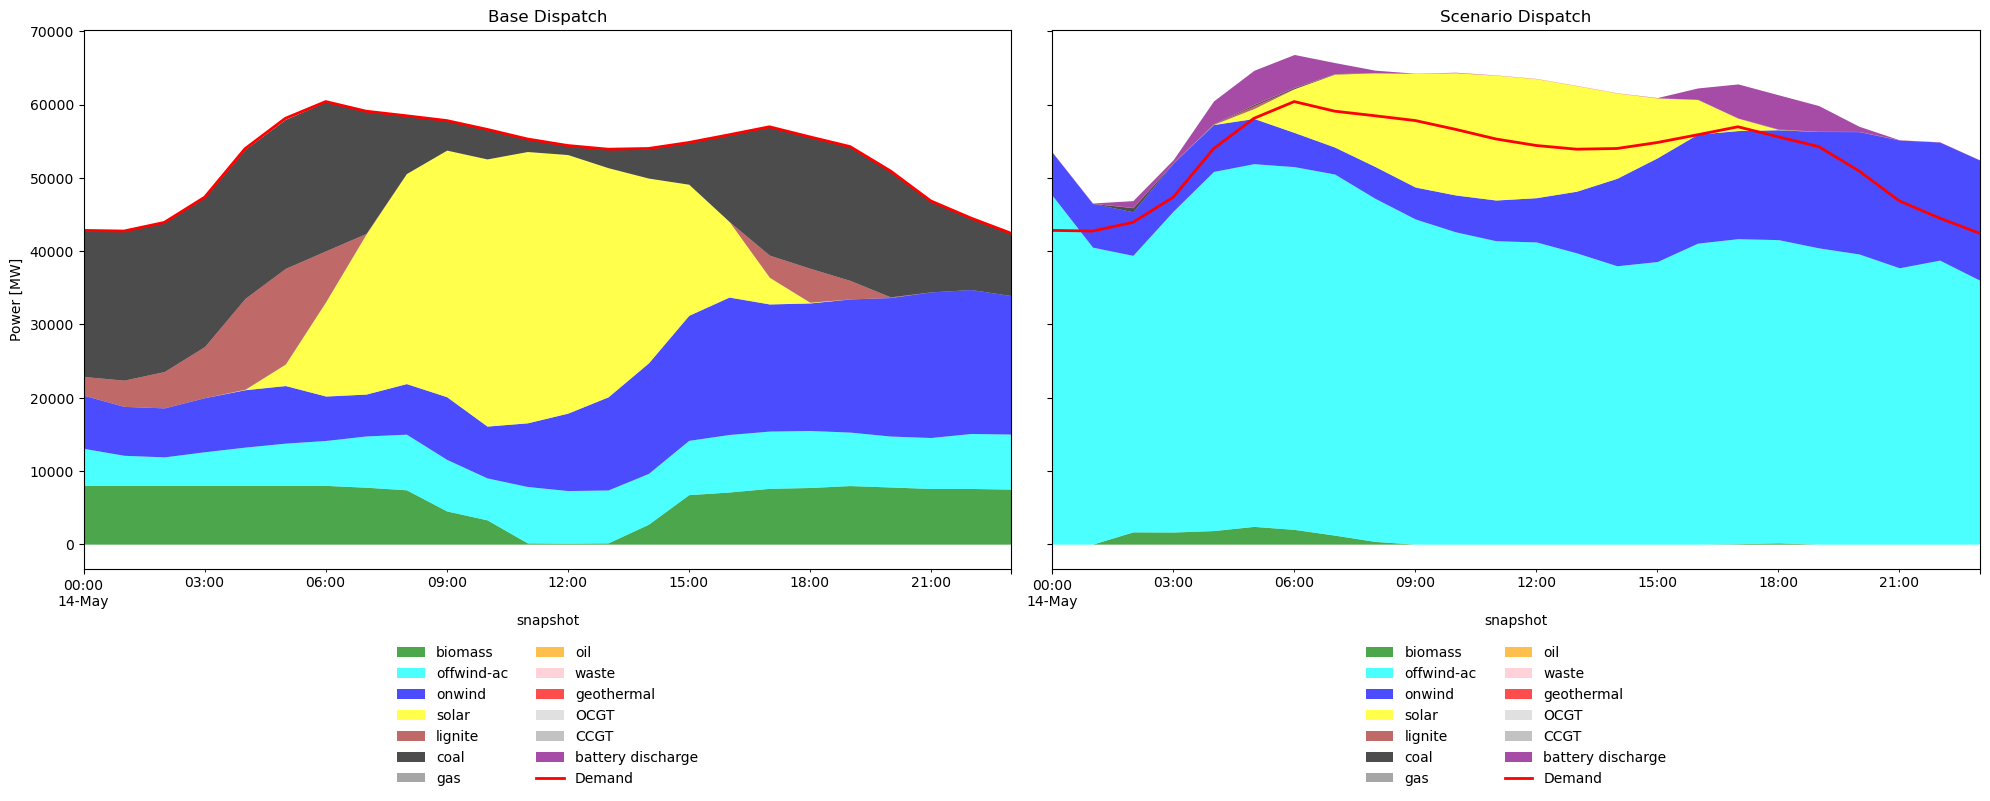

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "gray", "oil": "orange", "waste": "pink", "geothermal": "red",
    "OCGT": "lightgray", "CCGT": "darkgray", "battery discharge": "purple"
}

cols = [
    "biomass", "offwind-ac", "onwind", "solar", "lignite", "coal", "gas", "oil", "waste", "geothermal", "OCGT", "CCGT", "battery discharge"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n_base, axes[0], "Base Dispatch")
plot_dispatch(n_scenario, axes[1], "Scenario Dispatch")

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

##### Total Energy Production by Carrier

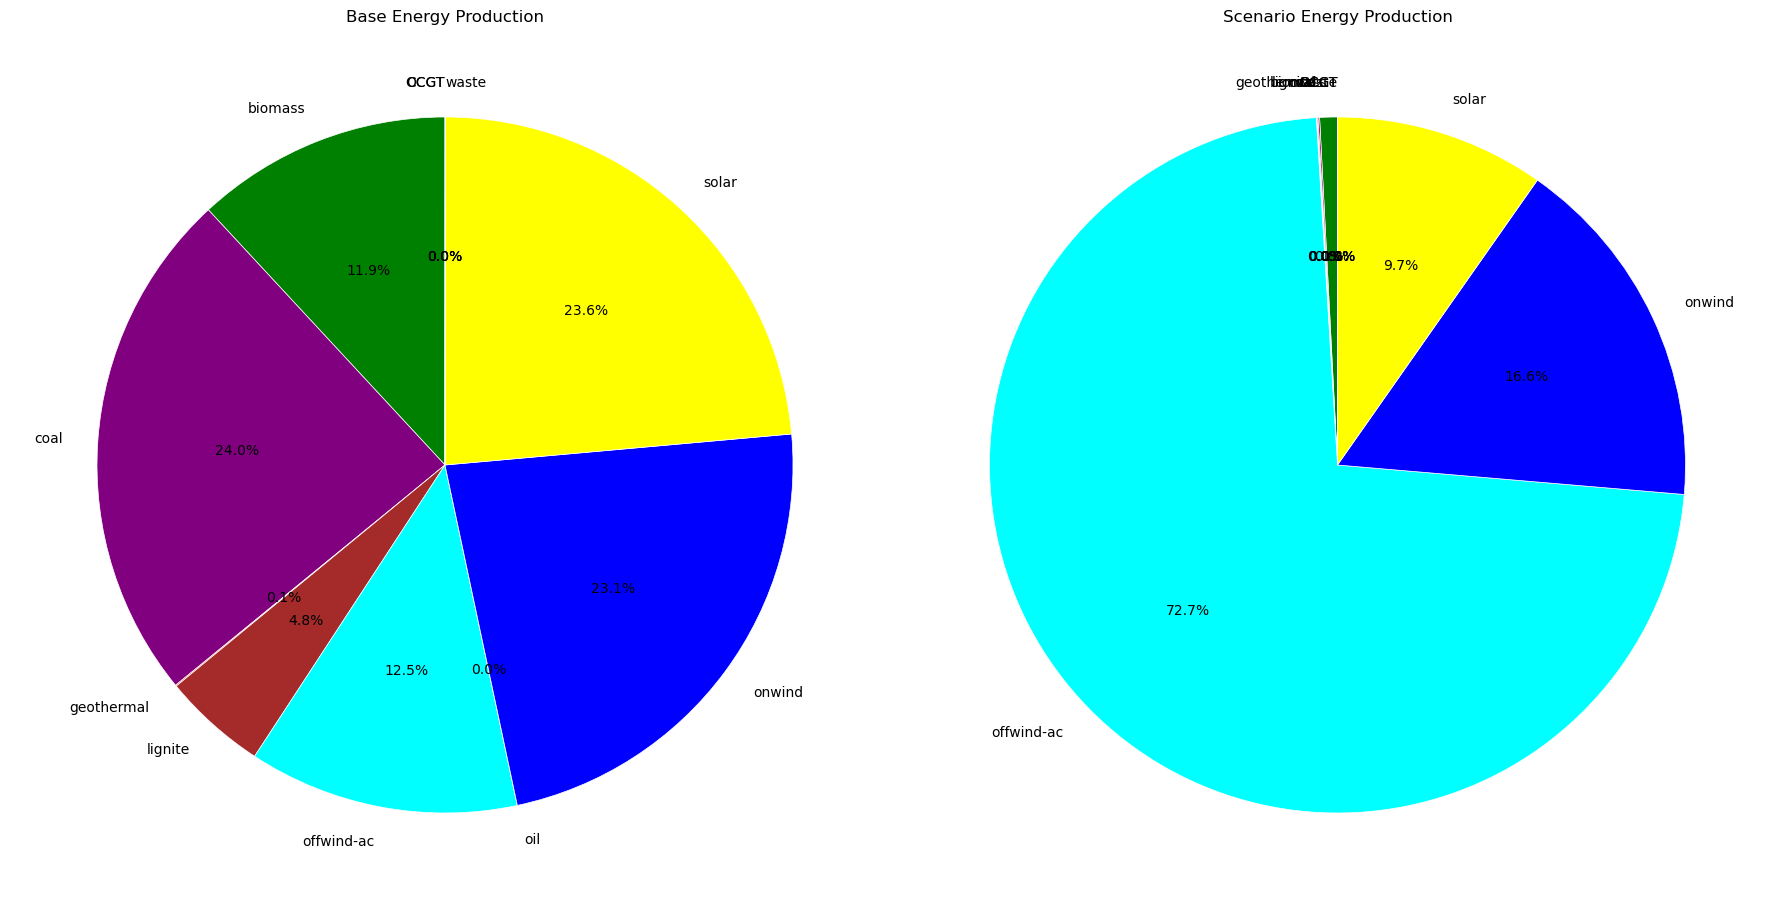

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# --- Define Colors and Order (same as dispatch plot) ---
colors = {
    "biomass": "green", "coal": "purple", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "purple", "oil": "orange", "waste": "pink", "geothermal": "red",
    "OCGT": "lightgray", "CCGT": "darkgray", "load": "red"
}

# --- Helper function for plotting pie chart ---
def plot_energy_pie(p_by_carrier, ax, title):
    energy_total = p_by_carrier.sum()
    # Filter out carriers with zero or negligible energy
    energy_total = energy_total[energy_total > 0.1]
    
    # Get colors for the carriers that are present
    pie_colors = [colors.get(carrier, "grey") for carrier in energy_total.index]

    energy_total.plot(
        kind="pie", 
        ax=ax, 
        autopct='%1.1f%%', 
        startangle=90, 
        title=title,
        colors=pie_colors,
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'} # Add white borders for clarity
    )
    ax.set_ylabel("")

# --- Calculate energy production for each scenario ---
p_by_carrier_base = n_base.generators_t.p.T.groupby(n_base.generators.carrier).sum().T
p_by_carrier_scenario = n_scenario.generators_t.p.T.groupby(n_scenario.generators.carrier).sum().T


# --- Plotting ---
plot_energy_pie(p_by_carrier_base, axes[0], "Base Energy Production")
plot_energy_pie(p_by_carrier_scenario, axes[1], "Scenario Energy Production")


plt.tight_layout()
plt.show()

### 4.3 Energy Balance


##### Unserved Energy Analysis


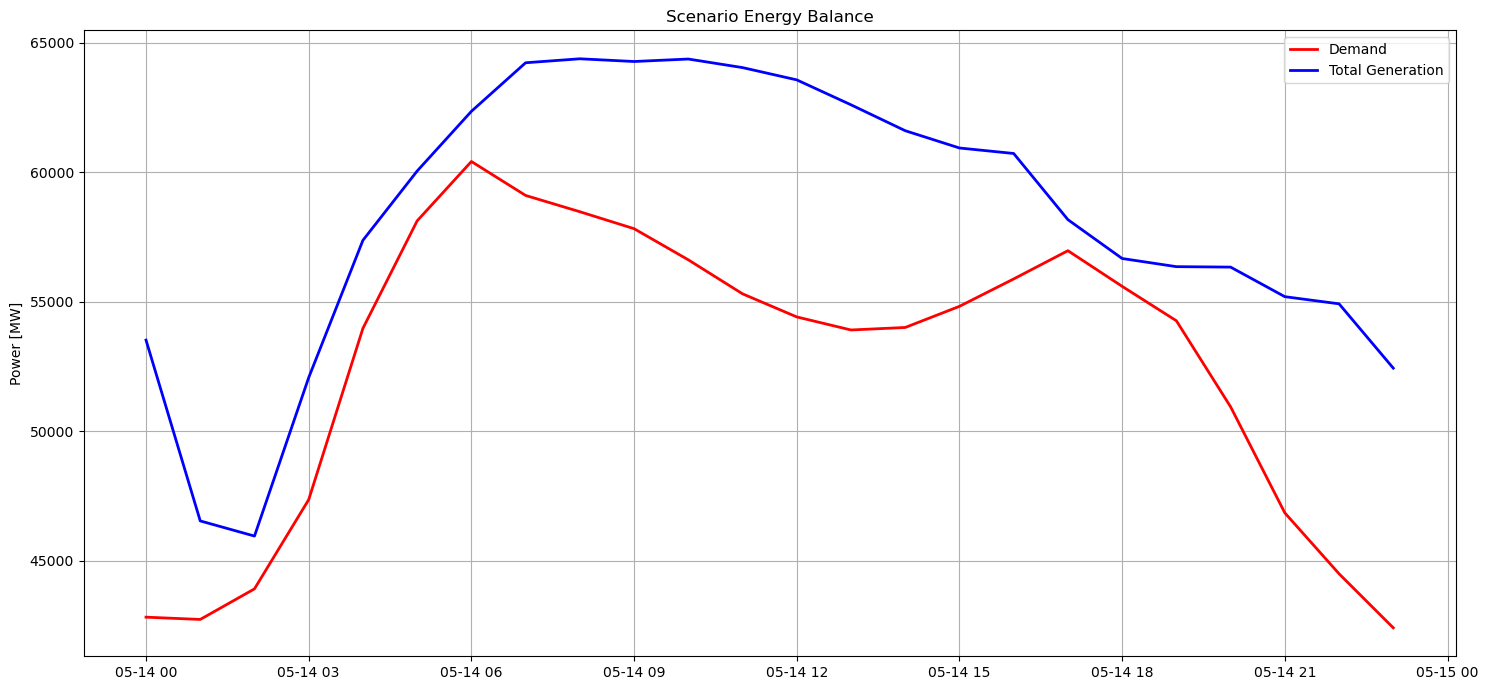

In [127]:
# --- Get Data ---
# Total generation from power plants
total_generation = p_by_carrier_scenario.sum(axis=1)

# Power consumed by Link components
link_dispatch = n_scenario.links_t.p0.T.groupby(n_scenario.links.carrier).sum().T
link_dispatch = link_dispatch.loc[:, (link_dispatch.abs().sum() > 0.1)]

# Isolate battery charging and discharging
battery_charge = link_dispatch['battery charger'] if 'battery charger' in link_dispatch else pd.Series(0, index=link_dispatch.index)
# Discharging is negative from the link's perspective, so we make it positive
battery_discharge = -link_dispatch['battery discharger'] if 'battery discharger' in link_dispatch else pd.Series(0, index=link_dispatch.index)

# Electricity demand
demand = n_scenario.loads_t.p_set.sum(axis=1)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(15, 7))

# Plot Demand and Generation as lines
ax.plot(demand.index, demand, color='red', lw=2, label='Demand')
ax.plot(total_generation.index, total_generation, color='blue', lw=2, label='Total Generation')


# --- Final Touches ---
ax.set_title('Scenario Energy Balance')
ax.set_ylabel('Power [MW]')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [128]:
# Build an electricity-system balance per bus and snapshot.
def _group_sum(df, labels):
    if df.empty:
        return pd.DataFrame(index=n_scenario.snapshots)
    return df.T.groupby(labels).sum().T

bus_balance = _group_sum(n_scenario.generators_t.p, n_scenario.generators.bus)
bus_balance = bus_balance.add(-_group_sum(n_scenario.loads_t.p_set, n_scenario.loads.bus), fill_value=0)

if not n_scenario.storage_units.empty:
    bus_balance = bus_balance.add(_group_sum(n_scenario.storage_units_t.p, n_scenario.storage_units.bus), fill_value=0)

if not n_scenario.stores.empty:
    bus_balance = bus_balance.add(_group_sum(n_scenario.stores_t.p, n_scenario.stores.bus), fill_value=0)

if not n_scenario.links.empty:
    bus_balance = bus_balance.add(-_group_sum(n_scenario.links_t.p0, n_scenario.links.bus0), fill_value=0)
    bus_balance = bus_balance.add(-_group_sum(n_scenario.links_t.p1, n_scenario.links.bus1), fill_value=0)

if not n_scenario.lines.empty:
    bus_balance = bus_balance.add(-_group_sum(n_scenario.lines_t.p0, n_scenario.lines.bus0), fill_value=0)
    bus_balance = bus_balance.add(-_group_sum(n_scenario.lines_t.p1, n_scenario.lines.bus1), fill_value=0)

if not n_scenario.transformers.empty:
    bus_balance = bus_balance.add(-_group_sum(n_scenario.transformers_t.p0, n_scenario.transformers.bus0), fill_value=0)
    bus_balance = bus_balance.add(-_group_sum(n_scenario.transformers_t.p1, n_scenario.transformers.bus1), fill_value=0)

# Residual balance per hour after summing across all buses.
hourly_residual = bus_balance.sum(axis=1)

# Report absolute and relative size of the mismatch.
total_abs_residual_mwh = hourly_residual.abs().sum()
total_residual_mwh = hourly_residual.sum()
peak_hourly_residual_mw = hourly_residual.abs().max()
relative_residual_pct = 100 * total_abs_residual_mwh / demand.sum()

print("--- Full Bus Balance Check (Scenario) ---")
print(f"Total absolute residual: {total_abs_residual_mwh:,.2f} MWh")
print(f"Net residual over horizon: {total_residual_mwh:,.2f} MWh")
print(f"Peak hourly residual: {peak_hourly_residual_mw:,.2f} MW")
print(f"Residual as share of total demand: {relative_residual_pct:.4f}%")
print("----------------------------------------------------")

if total_abs_residual_mwh < 1 and peak_hourly_residual_mw < 1:
    print("The remaining imbalance is just numerical noise.")
elif relative_residual_pct < 0.1:
    print("The residual is small relative to total demand and can likely be neglected in the overall picture.")
else:
    print("The residual is not negligible and should be investigated further.")

# Optional: show the buses with the largest net residual over the horizon.
bus_residual = bus_balance.sum(axis=0).sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTop buses by net residual over the horizon:")
print(bus_residual.head(10))

--- Full Bus Balance Check (Scenario) ---
Total absolute residual: 0.00 MWh
Net residual over horizon: 0.00 MWh
Peak hourly residual: 0.00 MW
Residual as share of total demand: 0.0000%
----------------------------------------------------
The remaining imbalance is just numerical noise.

Top buses by net residual over the horizon:
DE0 415    1.664375e-10
DE0 150   -1.100489e-10
DE0 382    1.016360e-10
DE0 202   -8.154188e-11
DE0 358   -7.904821e-11
DE0 296   -4.857270e-11
DE0 255    4.748557e-11
DE0 203    4.638423e-11
DE0 117    4.382619e-11
DE0 124    4.222045e-11
dtype: float64


In [129]:
#n_scenario.components.buses.static